<a href="https://colab.research.google.com/github/amankr2301/-Text-Based-Sentiment-Prediction-/blob/main/simple_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/economic_index.csv")

In [ ]:
df.columns

Index(['Unnamed: 0', 'year', 'month', 'interest_rate', 'unemployment_rate',
       'index_price'],
      dtype='object')

In [ ]:
## Drop unncessary columns
df.drop(['Unnamed: 0' , 'year' , 'month' ], axis = 1 , inplace = True)

In [ ]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [ ]:
df.isnull().sum()

,0
interest_rate,0
unemployment_rate,0
index_price,0


<Axes: >

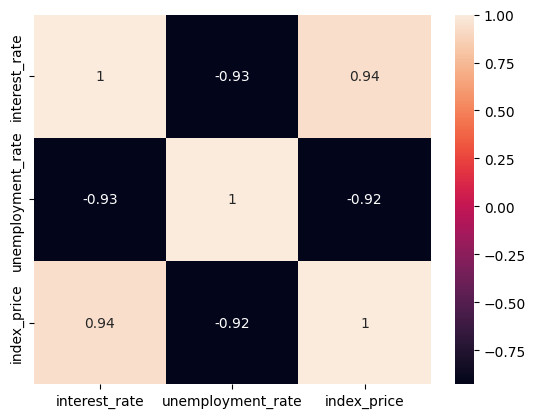

In [ ]:
sns.heatmap(df.corr() , annot = True)

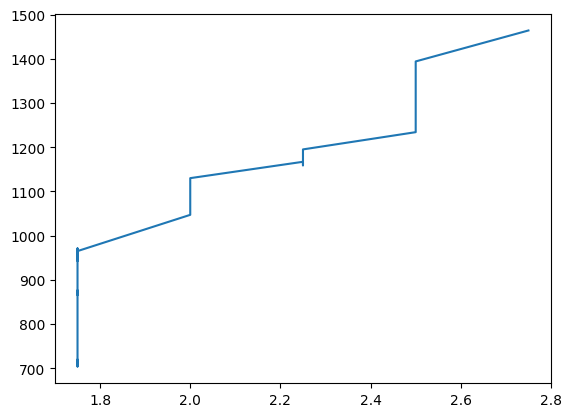

In [ ]:
plt.plot(df['interest_rate'] , df['index_price'])

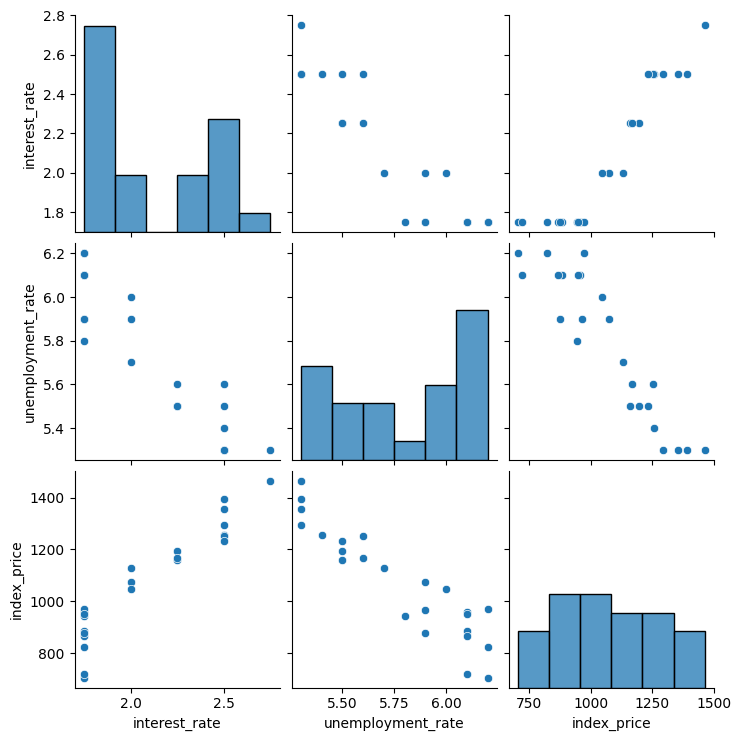

In [ ]:
sns.pairplot(df)

Text(0, 0.5, 'Unemployment_rate')

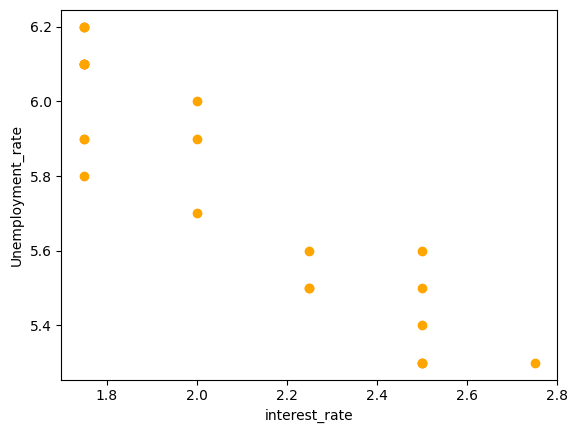

In [ ]:
plt.scatter(df['interest_rate'] , df['unemployment_rate'] , color = 'orange')
plt.xlabel('interest_rate')
plt.ylabel('Unemployment_rate')

In [ ]:
x = df.drop('index_price' , axis = 1)
y = df['index_price']

In [ ]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.25 , random_state = 42)

In [ ]:
## standard scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [ ]:
x_train = scaler.fit_transform(x_train)

In [ ]:
x_test = scaler.transform(x_test)

In [ ]:
df.select_dtypes(include = ('object')).columns

Index([], dtype='object')

In [ ]:
df.select_dtypes(exclude = ('object')).columns

Index(['interest_rate', 'unemployment_rate', 'index_price'], dtype='object')

In [ ]:
df.select_dtypes(include = np.number).columns

Index(['interest_rate', 'unemployment_rate', 'index_price'], dtype='object')

In [ ]:
regressor = LinearRegression()

In [ ]:
regressor.fit(x_train , y_train)

LinearRegression()

In [ ]:
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(regressor , x_train , y_train , cv = 5 , scoring = 'neg_mean_squared_error')

In [ ]:
np.mean(validation_score)

np.float64(-5649.115244350758)

In [ ]:
y_preds = regressor.predict(x_test)

In [ ]:
pd.DataFrame({'Prediction' : y_preds ,
              'Actual': y_test})

,Prediction,Actual
8,1204.227704,1159
16,821.650519,971
0,1406.513004,1464
18,857.708896,884
11,994.909923,1075
9,1168.169327,1167


In [ ]:
## Metrics
from sklearn.metrics import mean_absolute_error , mean_squared_error

In [ ]:
mse = mean_squared_error(y_preds , y_test)
mae = mean_absolute_error(y_preds ,y_test)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

5793.762887712569
59.935781523235484
76.11677139574805


In [ ]:
from sklearn.metrics import r2_score
score = r2_score(y_preds , y_test)

In [ ]:
score

0.8626502528670701